# Chapter 4 Lab: Logistic Regression, LDA, QDA, and KNN

This lab aims to predict whether the stock market went **Up** or **Down** on a given day using several classification methods, and compare how they perform:

1. **Logistic Regression**
2. **Linear Discriminant Analysis (LDA)**
3. **Quadratic Discriminant Analysis (QDA)**
4. **Naive Bayes**
5. **K-Nearest Neighbors (KNN)**

Each section includes a short explanation of *what* the method is doing and *why*, followed by the working code and the results.

**Data sets used:**
- `Smarket` — daily percentage returns of the S&P 500 index, 2001–2005 (used for logistic regression, LDA, QDA, naive Bayes, KNN)
- `Caravan` — demographic data on individuals, used to predict whether they purchase caravan insurance (used to show KNN on a more realistic, higher-dimensional problem)


## 0. Setup

We import the libraries needed throughout the lab. Nothing new here that you haven't seen in earlier chapters, plus a handful of new imports specific to classification.


In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

In [2]:
# New imports needed for this lab
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
    (LinearDiscriminantAnalysis as LDA,
     QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## 4.7.1 The Stock Market Data

The `Smarket` data set (part of `ISLP`) contains percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005.

For each day we have:
- `Lag1`–`Lag5`: percentage returns for each of the five previous trading days
- `Volume`: number of shares traded the previous day (in billions)
- `Today`: percentage return **on** the day in question
- `Direction`: whether the market was `Up` or `Down` that day (this is what we want to predict)


In [3]:
Smarket = load_data('Smarket')
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [4]:
Smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


We compute the correlation matrix (excluding the qualitative `Direction` column, which `.corr()` automatically drops). As you'd expect for stock returns, the lagged-return variables are essentially uncorrelated with each other and with `Today` — the only sizeable correlation is between `Year` and `Volume` (trading volume increased over the 5-year period).


In [5]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


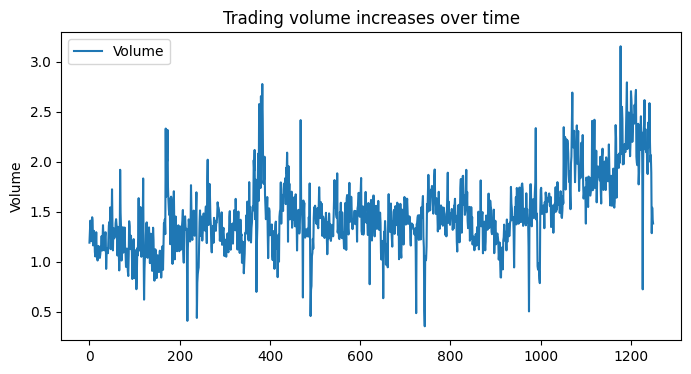

In [6]:
fig, ax = subplots(figsize=(8, 4))
Smarket.plot(y='Volume', ax=ax)
ax.set_ylabel('Volume')
ax.set_title('Trading volume increases over time');

## 4.7.2 Logistic Regression

**Idea:** Instead of modeling the response directly (which doesn't make sense for a 0/1 outcome), logistic regression models the *probability* that `Direction = Up`, using the logistic function

$$p(X) = \frac{e^{\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p}}{1 + e^{\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p}}$$

which always stays between 0 and 1, no matter what the predictors are. We fit this model to predict `Direction` using `Lag1`–`Lag5` and `Volume`.

We use `sm.GLM()` (a Generalized Linear Model) with `family=sm.families.Binomial()`, which tells `statsmodels` to fit a logistic regression rather than ordinary linear regression.


In [7]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'
glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


The smallest p-value belongs to `Lag1`, but at 0.15 it's still fairly large — there's no strong evidence that any single predictor is associated with `Direction`. This isn't too surprising for stock returns!

We can pull out just the coefficients or just the p-values if we want them individually:


In [8]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [9]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

### Making predictions

`results.predict()` returns the *predicted probability* that the market goes up, $P(Y=1|X)$. With no data supplied, it computes probabilities for the training data.


In [10]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

To turn probabilities into class labels we apply a 50% threshold: if the predicted probability of `Up` exceeds 0.5, we predict `Up`, otherwise `Down`.


In [11]:
labels = np.array(['Down'] * 1250)
labels[probs > 0.5] = 'Up'

`confusion_table()` (from `ISLP`) tallies correct vs. incorrect predictions. Rows are our predicted labels; columns are the true labels.


In [12]:
confusion_table(labels, Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


In [13]:
(507 + 145) / 1250, np.mean(labels == Smarket.Direction)

(0.5216, np.float64(0.5216))

So logistic regression is right about 52.2% of the time — **on the training data it was fit on**, which overstates how well it would do on new data. To get an honest estimate of test performance we need to fit on one period and evaluate on another.

### Train/test split by year

We train on days **before 2005** and test on days **during 2005** — a realistic setup, since in practice we'd only have past data available.


In [14]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

In [15]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]

glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [16]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]

labels = np.array(['Down'] * 252)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [17]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.4801587301587302), np.float64(0.5198412698412699))

The test error rate is about **52%** — *worse* than random guessing! This makes sense: past returns are essentially uninformative about future returns, and using all six noisy predictors (`Lag1`–`Lag5`, `Volume`) adds variance without adding useful signal.

### A leaner model

Since `Lag1` and `Lag2` had the (relatively) strongest signal, let's refit using just those two predictors and see whether dropping the uninformative ones helps.


In [18]:
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train, X_test = X.loc[train], X.loc[~train]

glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

labels = np.array(['Down'] * 252)
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [19]:
(35 + 106) / 252, 106 / (106 + 76)

(0.5595238095238095, 0.5824175824175825)

Now 56% of the days are predicted correctly overall. Interestingly, a naive strategy of *always* predicting `Up` would also be right 56% of the time (the market goes up more often than down over this period) — so the overall accuracy isn't impressive. **But** on the days when the model predicts an increase, it's right 58% of the time, which hints at a possible trading rule: only trade on days the model predicts `Up`.

We can also get predictions for brand-new hypothetical days:


In [20]:
newdata = pd.DataFrame({'Lag1': [1.2, 1.5],
                         'Lag2': [1.1, -0.8]})
newX = model.transform(newdata)
results.predict(newX)

0    0.479146
1    0.496094
dtype: float64

## 4.7.3 Linear Discriminant Analysis (LDA)

**Idea:** Rather than modeling $P(Y|X)$ directly (as logistic regression does), LDA models the distribution of the predictors *within each class* — assuming they're (multivariate) Normal with a shared covariance matrix — and then uses Bayes' theorem to flip this around into $P(Y|X)$. This produces a *linear* decision boundary, much like logistic regression, but the two methods estimate the boundary differently and can behave differently in practice (LDA tends to work better when the Normal assumption approximately holds, or when classes are well separated).

We fit LDA on the pre-2005 training data using `Lag1` and `Lag2`. Since the LDA estimator adds its own intercept internally, we drop the `intercept` column that `ModelSpec` added.


In [21]:
lda = LDA(store_covariance=True)

X_train, X_test = [M.drop(columns=['intercept'])
                    for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


`means_` holds the average of `Lag1`/`Lag2` within each class — these are LDA's estimates of $\mu_k$. Notice returns tend to be *negative* on days the market goes on to rise, and *positive* on days it falls — a subtle mean-reversion pattern.


In [22]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [23]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

`priors_` are the estimated class proportions $\hat\pi_k$ — about 49% `Down`, 51% `Up` in the training period.


In [24]:
lda.priors_

array([0.49198397, 0.50801603])

`scalings_` gives the linear-discriminant coefficients: the combination $-0.64\times\text{Lag1} - 0.51\times\text{Lag2}$ that LDA uses to separate the classes. A large value points toward `Up`; a small (very negative) value points toward `Down`.


In [25]:
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

In [26]:
lda_pred = lda.predict(X_test)
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


As expected, LDA and logistic regression give nearly identical predictions on this data set.

`predict_proba()` gives the posterior probability of each class. Applying a 50% cutoff to these probabilities exactly reproduces `lda_pred`:


In [27]:
lda_prob = lda.predict_proba(X_test)
np.all(
    np.where(lda_prob[:, 1] >= 0.5, 'Up', 'Down') == lda_pred
)

np.True_

In [28]:
np.all(
    [lda.classes_[i] for i in np.argmax(lda_prob, 1)] == lda_pred
)

np.True_

We could also use a stricter threshold if we only want to predict `Down` when we're very confident. For example, requiring at least 90% posterior probability of a decline:


In [29]:
np.sum(lda_prob[:, 0] > 0.9)

np.int64(0)

Zero days meet that bar — the most confident `Down` prediction in all of 2005 was only about 52%. Stock-market direction is genuinely hard to predict!


## 4.7.4 Quadratic Discriminant Analysis (QDA)

**Idea:** QDA relaxes LDA's assumption of a *shared* covariance matrix across classes — instead it lets each class have its own covariance matrix. This gives a more flexible, *quadratic* decision boundary. More flexibility means lower bias but higher variance, so QDA tends to help when classes have genuinely different spreads/correlations and there's enough data to estimate the extra parameters reliably.

The syntax mirrors `LDA()` exactly.


In [30]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [31]:
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

QDA estimates one covariance matrix *per class*. Here's the estimated covariance matrix for the `Down` class:


In [32]:
qda.covariance_[0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

In [33]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


In [34]:
np.mean(qda_pred == L_test)

np.float64(0.5992063492063492)

QDA gets almost **60%** accuracy on the 2005 test data — noticeably better than LDA or logistic regression here, suggesting the true decision boundary may be closer to quadratic than linear. That said, this is a single test set from famously noisy data, so we shouldn't get too excited before checking on more data.


## 4.7.5 Naive Bayes

**Idea:** Naive Bayes also models each class's predictor distribution and applies Bayes' theorem, but makes a simplifying (and usually wrong, but often still useful!) assumption: *within each class, the predictors are independent of one another*. This means we only need to estimate a 1-D distribution per predictor per class, rather than a full covariance matrix — cheaper and less variance, at the cost of some bias if predictors are actually correlated. By default `GaussianNB()` models each predictor within each class using a univariate Normal distribution.


In [35]:
NB = GaussianNB()
NB.fit(X_train, L_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [36]:
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [37]:
NB.class_prior_

array([0.49198397, 0.50801603])

`theta_` holds the estimated mean and `var_` the estimated variance of each feature within each class.


In [38]:
NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [39]:
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

We can verify these are just the per-class sample mean/variance:


In [40]:
X_train[L_train == 'Down'].mean()

Lag1    0.042790
Lag2    0.033894
dtype: float64

In [41]:
X_train[L_train == 'Down'].var(ddof=0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

In [42]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [43]:
np.mean(nb_labels == L_test)

np.float64(0.5952380952380952)

Naive Bayes gets just over **59%** — slightly behind QDA but noticeably ahead of LDA/logistic regression on this test set.

Like LDA and QDA, `predict_proba()` gives posterior class probabilities:


In [44]:
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

## 4.7.6 K-Nearest Neighbors (KNN)

**Idea:** KNN takes a completely different, *non-parametric* approach — no assumptions about the shape of the decision boundary at all. To classify a new point, it looks at the $K$ *closest* training points (by Euclidean distance) and predicts whatever class is most common among them. Small $K$ gives a very flexible (low-bias, high-variance) fit; large $K$ gives a smoother (higher-bias, lower-variance) fit.

### KNN on the Smarket data


In [45]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


In [46]:
(83 + 43) / 252, np.mean(knn1_pred == L_test)

(0.5, np.float64(0.5))

With $K=1$ we only get 50% accuracy — no better than a coin flip. $K=1$ is extremely flexible and likely overfits the noisy training data. Let's try $K=3$:


In [47]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train, L_train).predict(X_test)
np.mean(knn3_pred == L_test)

np.float64(0.5317460317460317)

A small improvement, but increasing $K$ further doesn't help much more. For the Smarket data, **QDA remains the best of the methods we've tried** — the market's decision boundary just doesn't seem to have the kind of local, non-linear structure that KNN is good at exploiting, and $n$ is fairly small relative to how noisy the data is.

KNN often shines on other problems, though. Let's see it applied to a data set where the classes have more genuine local structure: the `Caravan` insurance data.

### KNN on the Caravan insurance data

`Caravan` contains 85 demographic predictors for 5,822 individuals, and the response `Purchase` indicates whether each person bought caravan insurance. Only about 6% did — a highly imbalanced outcome.


In [48]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

In [49]:
348 / 5822

0.05977327378907592

In [50]:
feature_df = Caravan.drop(columns=['Purchase'])

**Why scaling matters for KNN:** KNN measures distance directly using the raw values of the predictors. A variable measured on a large scale (e.g. salary in dollars) will dominate the distance calculation compared to a variable on a small scale (e.g. age in years), even if age is just as important. The fix is to **standardize** every predictor to have mean 0 and standard deviation 1, using `StandardScaler`.


In [51]:
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)
scaler.fit(feature_df)
X_std = scaler.transform(feature_df)

In [52]:
feature_std = pd.DataFrame(X_std, columns=feature_df.columns)
feature_std.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

Now we split into a training set and a 1,000-observation test set.


In [53]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(feature_std,
                             Purchase,
                             test_size=1000,
                             random_state=0)

In [54]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn1_pred), np.mean(y_test != 'No')

(np.float64(0.111), np.float64(0.067))

The KNN error rate (~11%) actually looks *worse* than the **null rate** of always predicting `No` (~6.7% error, since so few people buy insurance)! But raw error rate is the wrong thing to optimize here — a company deciding *who to try to sell insurance to* only cares about how many of its *predicted buyers* actually buy. Predicting `No` for everyone is "accurate" but useless for that purpose.


In [55]:
confusion_table(knn1_pred, y_test)

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [56]:
9 / (53 + 9)

0.14516129032258066

Among the people KNN predicts *would* buy insurance, about **14.5%** actually do — more than double the 6% base rate. That's a real, useful signal for a sales team, even though the overall accuracy number looked unimpressive.

### Tuning K

$K$ is a **hyperparameter** — we don't know the best value in advance, so we try several and see which does best on the test set (in practice, cross-validation, covered in Chapter 5, is the more rigorous way to choose it).


In [57]:
for K in range(1, 6):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    C = confusion_table(knn_pred, y_test)
    templ = ('K={0:d}: # predicted to rent: {1:>2},'
             + ' # who did rent {2:d}, accuracy {3:.1%}')
    pred = C.loc['Yes'].sum()
    did_rent = C.loc['Yes', 'Yes']
    print(templ.format(K, pred, did_rent, did_rent / pred if pred > 0 else float('nan')))

K=1: # predicted to rent: 62, # who did rent 9, accuracy 14.5%
K=2: # predicted to rent:  6, # who did rent 1, accuracy 16.7%
K=3: # predicted to rent: 20, # who did rent 3, accuracy 15.0%
K=4: # predicted to rent:  4, # who did rent 0, accuracy 0.0%
K=5: # predicted to rent:  7, # who did rent 1, accuracy 14.3%


Results bounce around quite a bit with so few positive cases in the test set — a reminder that with a rare outcome, small changes in $K$ can swing performance noticeably.

### Comparison to logistic regression

Finally, let's compare against logistic regression on the same data. `sklearn`'s `LogisticRegression` regularizes by default (similar to ridge regression, covered in Chapter 6); setting `C` very large effectively turns regularization off, matching the classic unregularized logistic regression from `statsmodels`.


In [58]:
logit = LogisticRegression(C=1e10, solver='liblinear')
logit.fit(X_train, y_train)
logit_pred = logit.predict_proba(X_test)
logit_labels = np.where(logit_pred[:, 1] > 0.5, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,931,67
Yes,2,0


With the standard 50% threshold, logistic regression predicts almost nobody will buy — and is wrong about most of those it does flag. Just like with LDA earlier, we're not required to use 0.5 as the cutoff. Lowering the threshold to 0.25 catches more true buyers:


In [59]:
logit_labels = np.where(logit_pred[:, 1] > 0.25, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


In [60]:
C = confusion_table(logit_labels, y_test)
C.loc['Yes', 'Yes'] / C.loc['Yes'].sum()

np.float64(0.3103448275862069)

With this lower threshold, roughly a third of the people logistic regression flags as likely buyers actually do buy — better than KNN managed, and over five times the random-guessing base rate.


## Summary

| Method | Test accuracy (Smarket 2005) | Notes |
|---|---|---|
| Logistic Regression (Lag1, Lag2) | 56.0% | Linear boundary; simple, interpretable |
| LDA | 56.0% | Linear boundary; nearly identical to logistic regression here |
| QDA | 59.9% | Quadratic boundary; best performer on this data set |
| Naive Bayes | 59.1% | Assumes independent predictors within each class |
| KNN (K=1) | 50.0% | Too flexible — overfits |
| KNN (K=3) | 53.2% | Slight improvement, still weakest method here |

**Key takeaways:**
- No single method dominates in general — the right choice depends on the true (unknown) shape of the decision boundary, how much data you have, and how many predictors you're using.
- LDA and logistic regression both assume a *linear* decision boundary and tend to agree closely, as we saw here.
- QDA and naive Bayes trade the shared-covariance assumption of LDA for more flexibility (QDA) or an independence assumption (naive Bayes) — either can win depending on the data.
- KNN makes no assumptions at all about the boundary shape, but needs a lot of data relative to the number of predictors to perform well, and is sensitive to the scale of the predictors (always standardize first!).
- Overall accuracy can be misleading with **imbalanced classes** (like `Caravan`) — always look at what you actually care about, e.g. the accuracy among *predicted positives*, not just the raw error rate.
